# LIBRERIAS

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import dask
import netCDF4
import xarray as xr
import rioxarray
import seaborn as sns
import math

# LECTURA DE DATOS

In [2]:
data_dir = Path("./Estaciones Aut - Precipitación")

data_files = list(data_dir.glob("*.data"))

print(f"Archivos encontrados: {len(data_files)}")

Archivos encontrados: 611


In [3]:
def read_climate_data(file_path, chunksize=300_000):
    chunks = []

    for chunk in pd.read_csv(
        file_path,
        sep="|",
        parse_dates=["Fecha"],
        dtype={"Valor": "float32"},
        chunksize=chunksize
    ):
        # Metadatos desde el nombre del archivo
        chunk["station_id"] = file_path.stem.split("@")[-1]
        chunk["variable"] = file_path.stem.split("@")[0]

        chunks.append(chunk)

    return pd.concat(chunks, ignore_index=True)

In [4]:
dfs = []

for file in data_files:
    df = read_climate_data(file)
    dfs.append(df)

climate_df = pd.concat(dfs, ignore_index=True)

In [5]:
print(climate_df.head())

                Fecha  Valor station_id   variable
0 2019-07-06 00:20:00    0.0   11017020  PT_AUT_10
1 2019-07-06 00:30:00    0.0   11017020  PT_AUT_10
2 2019-07-06 00:40:00    0.0   11017020  PT_AUT_10
3 2019-07-06 00:50:00    0.0   11017020  PT_AUT_10
4 2019-07-06 01:00:00    0.0   11017020  PT_AUT_10


# PUNTO 1

In [6]:
# df ya leído desde parquet
df = climate_df.sort_values("Fecha").set_index("Fecha")
station_id = "21206930"
df = df[df["station_id"] == station_id].copy()
# Opcional: filtrar mínimo 10 años
df = df.loc["2010-01-01":]

In [7]:
print(df.index.min(), df.index.max())

2010-01-01 07:00:00 2023-03-17 04:30:00


In [8]:
def precipitation_stats(df, freq):
    # Agregación temporal (suma)
    agg = df['Valor'].resample(freq).sum().dropna()

    # Estadísticos básicos
    mean = agg.mean()
    var = agg.var()
    cv = np.sqrt(var) / mean if mean > 0 else np.nan

    # Estados
    no_ll = agg == 0
    ll = (agg > 0) & (agg <= 1)
    li = agg > 1

    p1 = no_ll.mean()
    p2 = ll.mean()
    p3 = li.mean()

    p_ll = (agg > 0).mean()

    # Transiciones (Markov)
    states = (agg > 0).astype(int)  # 0 = NoLL, 1 = LL
    prev = states.shift(1).dropna()
    curr = states.iloc[1:]

    transitions = pd.crosstab(prev, curr, normalize='index')

    return {
        'Media': mean,
        'Varianza': var,
        'Coef_Variacion': cv,
        'p1': p1,
        'p2': p2,
        'p3': p3,
        'Prob_LL_y_NoLL': p_ll,
        'NoLL|NoLL': transitions.loc[0, 0] if (0 in transitions.index and 0 in transitions.columns) else np.nan,
        'LL|NoLL': transitions.loc[0, 1] if (0 in transitions.index and 1 in transitions.columns) else np.nan,
        'LL|LL': transitions.loc[1, 1] if (1 in transitions.index and 1 in transitions.columns) else np.nan,
        'NoLL|LL': transitions.loc[1, 0] if (1 in transitions.index and 0 in transitions.columns) else np.nan,
    }

In [9]:
freqs = {
    '10 min': '10min',
    '30 min': '30min',
    '1 hr': '1h',
    '3 hr': '3h',
    '6 hr': '6h',
    '12 hr': '12h',
    '24 hr': '24h'
}

Las gráficas desarrolladas en este análisis se basan en registros de precipitación con una resolución temporal de 10 minutos, provenientes de la estación meteorológica 21206930 Páramo Guerrero, ubicada en el municipio de Zipaquirá, departamento de Cundinamarca.

La siguiente tabla resume algunas estadísticas descriptivas clave del comportamiento de la precipitación para diferentes escalas temporales (Δt).

In [10]:
results = []

for label, freq in freqs.items():
    stats = precipitation_stats(df, freq)
    stats['Δt'] = label
    results.append(stats)

table = pd.DataFrame(results).set_index('Δt')
table

,Media,Varianza,Coef_Variacion,p1,p2,p3,Prob_LL_y_NoLL,NoLL|NoLL,LL|NoLL,LL|LL,NoLL|LL
Δt,,,,,,,,,,,
10 min,0.018006,0.025774,8.916161,0.947896,0.049007,0.003097,0.052104,0.977059,0.022941,0.582629,0.417371
30 min,0.054018,0.156877,7.332364,0.909218,0.077780,0.013002,0.090782,0.952756,0.047244,0.526789,0.473211
1 hr,0.108035,0.462072,6.292002,0.866920,0.107058,0.026022,0.133080,0.921162,0.078838,0.486367,0.513633
3 hr,0.324101,2.028127,4.394078,0.741966,0.187591,0.070444,0.258034,0.824746,0.175254,0.495982,0.504018
6 hr,0.648201,4.813454,3.384687,0.612637,0.259900,0.127462,0.387363,0.740672,0.259328,0.589802,0.410198
12 hr,1.296268,11.066868,2.566360,0.457241,0.314295,0.228465,0.542759,0.661528,0.338472,0.714804,0.285196
24 hr,2.592268,23.368086,1.864798,0.292081,0.311567,0.396352,0.707919,0.652236,0.347764,0.856473,0.143527


En términos generales, el coeficiente de variación presenta valores elevados en todos los intervalos de tiempo (Δt), lo cual es consistente con las altas varianzas observadas. Esto indica que la serie de tiempo de precipitación es altamente heterogénea, incluso en un entorno de alta montaña como el Páramo Guerrero.

A medida que aumenta Δt, se observa una disminución progresiva del coeficiente de variación, pasando de valores cercanos a 9 en escalas de 10 minutos a valores inferiores a 2 en intervalos de 24 horas. Este comportamiento sugiere una mayor estabilidad relativa al agregar la información en escalas temporales más amplias, aunque la variabilidad sigue siendo considerable.

Respecto a la estructura temporal, los valores asociados a p3 aumentan de manera consistente con Δt, lo que indica una mayor persistencia de la precipitación en escalas de tiempo más largas. Este patrón es especialmente evidente a partir de intervalos de 3 horas, donde la contribución de eventos de lluvia más prolongados comienza a ser más relevante.

En cuanto a las probabilidades condicionales, se observa que la probabilidad de lluvia dado que previamente llovió (LL|LL) aumenta de forma significativa con Δt, alcanzando valores superiores a 0.85 en intervalos de 24 horas. Esto evidencia una fuerte persistencia de eventos lluviosos en escalas temporales agregadas.

Por su parte, la probabilidad de transición de no lluvia a lluvia (LL|NoLL) también se incrementa con Δt, aunque se mantiene sistemáticamente por debajo de la persistencia de lluvia. Adicionalmente, la probabilidad de no lluvia dado que previamente no llovió (NoLL|NoLL) disminuye a medida que aumenta Δt, lo que sugiere que los periodos secos tienden a ser menos persistentes que los húmedos.

En conjunto, estos resultados indican que, aunque la precipitación en el Páramo Guerrero presenta una alta variabilidad en escalas cortas, existe una marcada persistencia de eventos de lluvia en escalas temporales mayores. Este comportamiento es consistente con las condiciones climáticas de ecosistemas de páramo, donde predominan eventos frecuentes de precipitación y alta humedad atmosférica.

# PUNTO 2

In [11]:
aggregated = {
    label: df['Valor'].resample(freq).sum().dropna()
    for label, freq in freqs.items()
}

In [12]:
def run_lengths(binary_series):
    lengths = []
    count = 0
    for v in binary_series:
        if v:
            count += 1
        else:
            if count > 0:
                lengths.append(count)
                count = 0
    if count > 0:
        lengths.append(count)
    return np.array(lengths)

In [13]:
def plot_hist_exp(data, title, xlabel):
    data = data[data > 0]

    if len(data) < 10:
        return

    lam = 1 / data.mean()

    x = np.linspace(data.min(), data.max(), 200)
    pdf = lam * np.exp(-lam * x)

    plt.figure()
    plt.hist(data, bins=30, density=True, alpha=0.6)
    plt.plot(x, pdf, linewidth=2)
    plt.xlabel(xlabel)
    plt.ylabel("Densidad")
    plt.title(title)
    plt.grid(True)
    plt.show()

In [14]:
def hist_exp_subplot(ax, data, title, xlabel):
    data = data[data > 0]

    if len(data) < 10:
        ax.set_title(title + " (insuficiente)")
        return

    lam = 1 / data.mean()
    x = np.linspace(data.min(), data.max(), 200)
    pdf = lam * np.exp(-lam * x)

    ax.hist(data, bins=30, density=True, alpha=0.6)
    ax.plot(x, pdf, linewidth=2)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel(xlabel, fontsize=8)
    ax.set_ylabel("Densidad", fontsize=8)
    ax.grid(True)

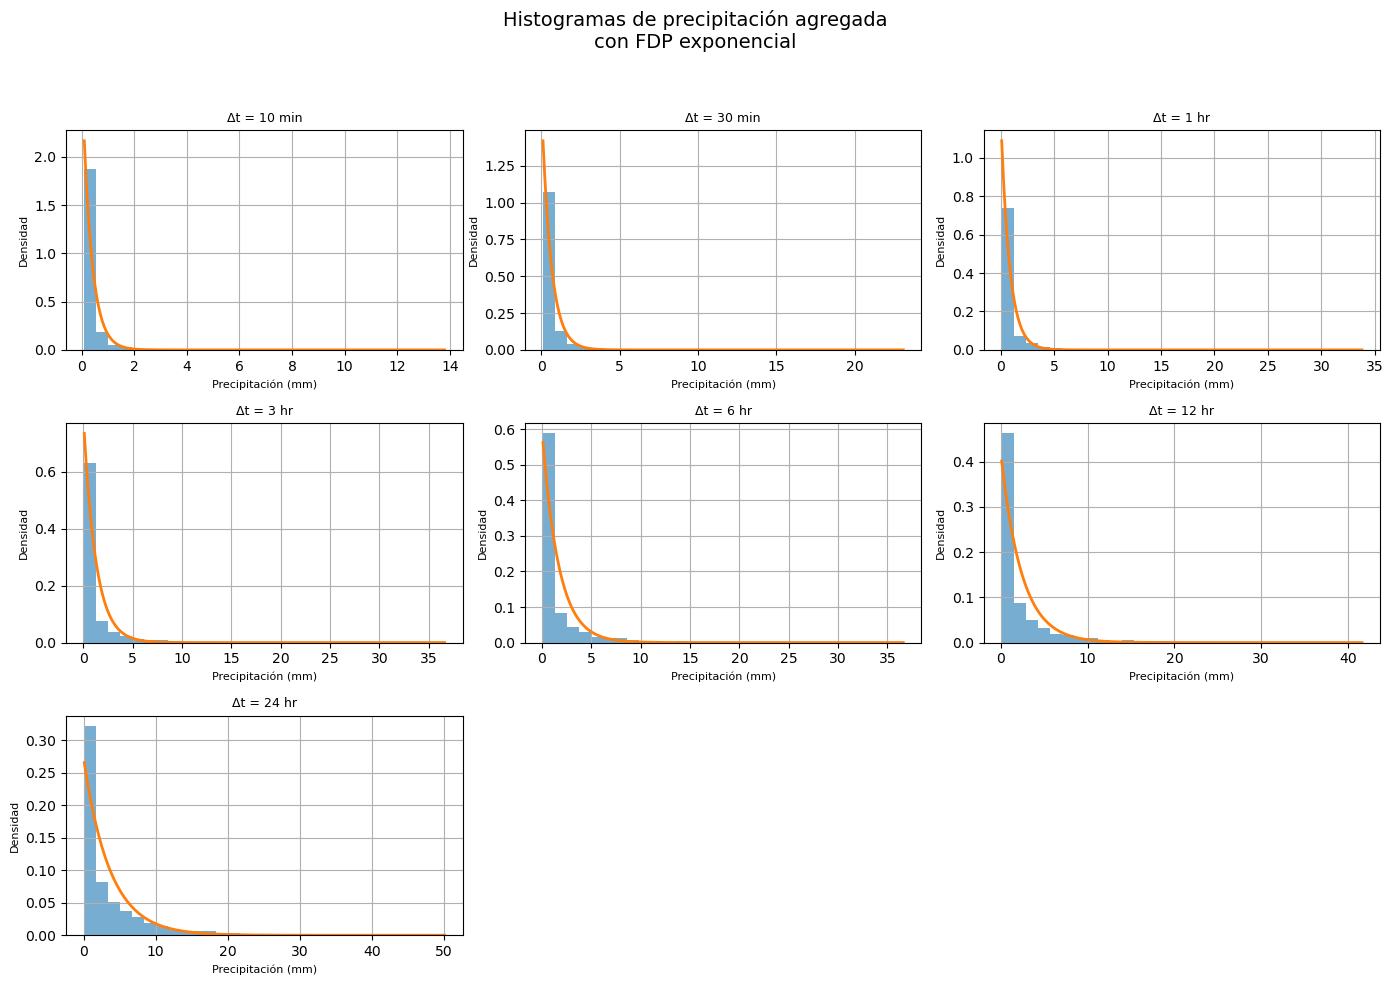

In [15]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, (label, series) in enumerate(aggregated.items()):
    hist_exp_subplot(
        axes[i],
        series.values,
        f"Δt = {label}",
        "Precipitación (mm)"
    )

# Eliminar subplots vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Histogramas de precipitación agregada\ncon FDP exponencial", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

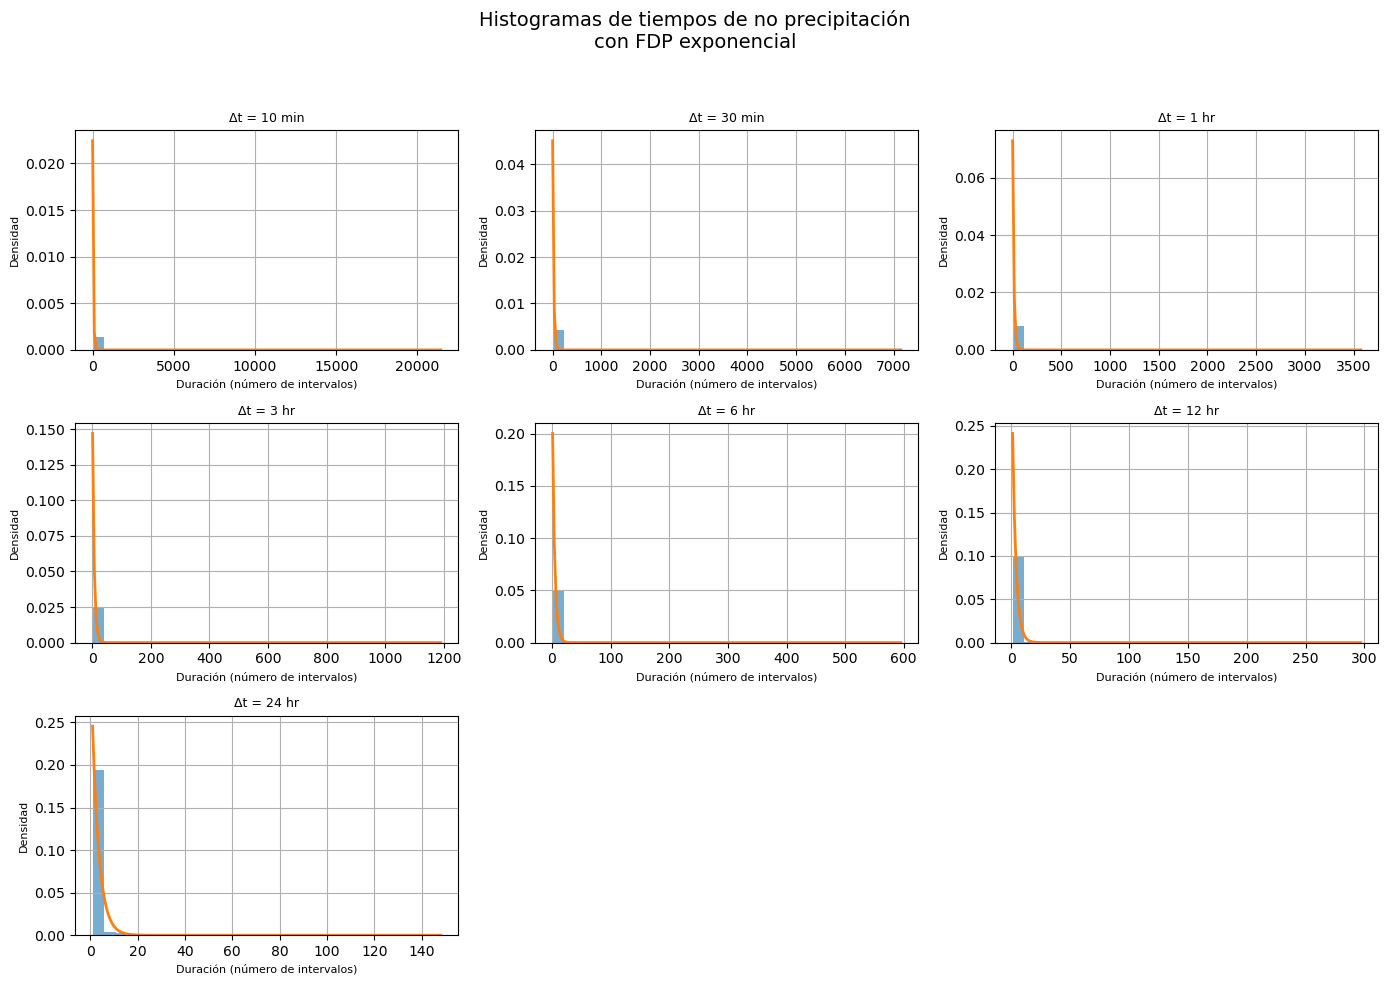

In [16]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, (label, series) in enumerate(aggregated.items()):
    dry = series == 0
    dry_runs = run_lengths(dry)

    hist_exp_subplot(
        axes[i],
        dry_runs,
        f"Δt = {label}",
        "Duración (número de intervalos)"
    )

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Histogramas de tiempos de no precipitación\ncon FDP exponencial", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

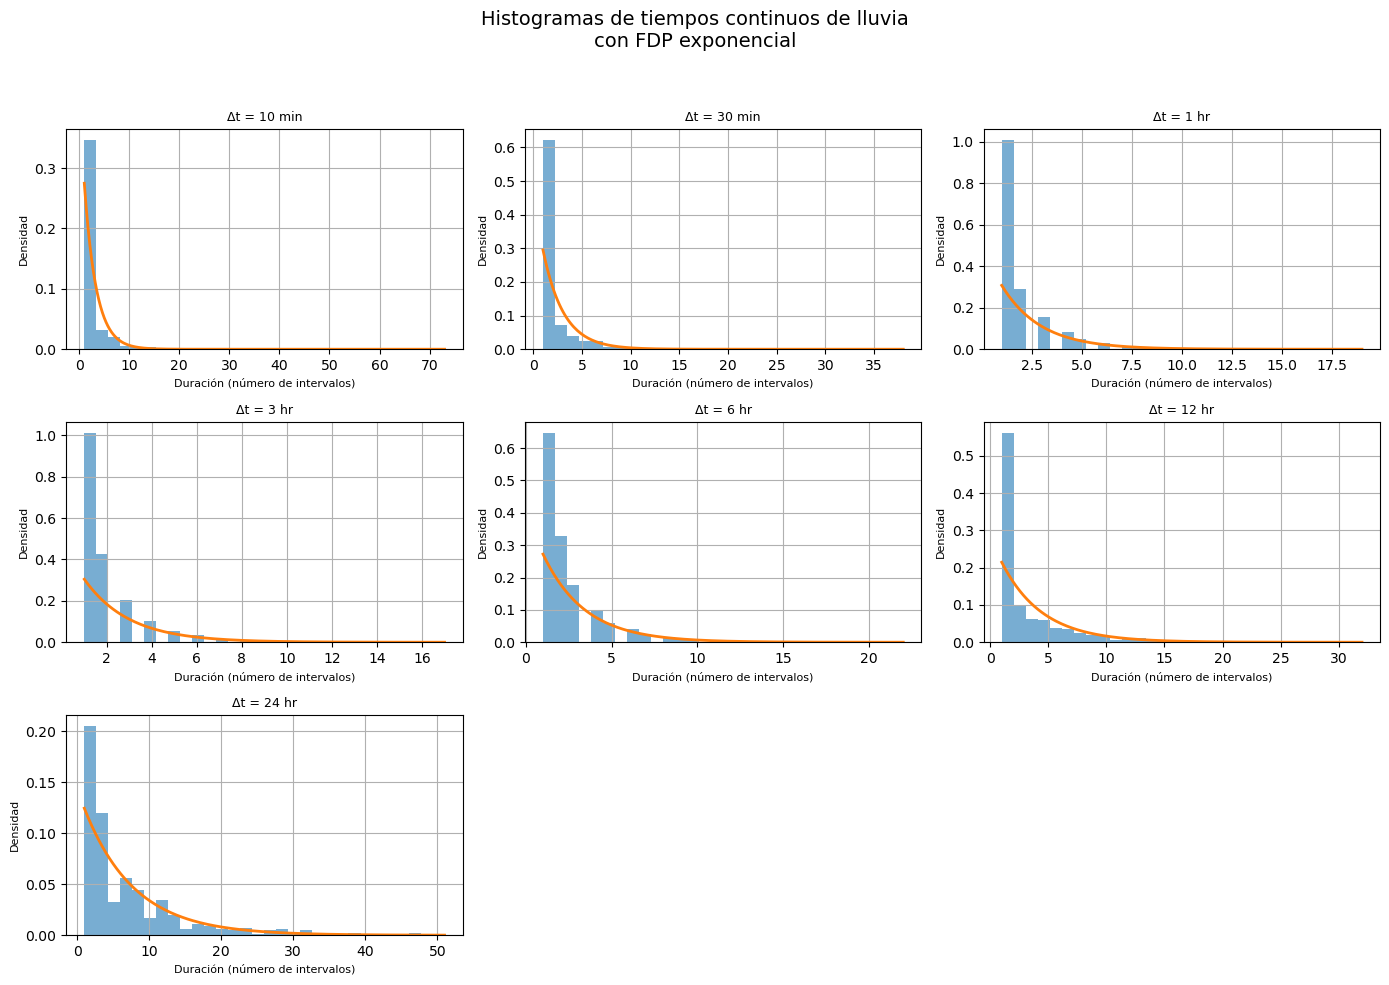

In [17]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, (label, series) in enumerate(aggregated.items()):
    wet = series > 0
    wet_runs = run_lengths(wet)

    hist_exp_subplot(
        axes[i],
        wet_runs,
        f"Δt = {label}",
        "Duración (número de intervalos)"
    )

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Histogramas de tiempos continuos de lluvia\ncon FDP exponencial", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Continuando el análisis con la información del punto anterior, la primera gráfica presenta la precipitación acumulada para intervalos de tiempo Δt de 10 min, 30 min, 1 hr, 3 hr, 6 hr, 12 hr y 24 hr, junto con su respectiva función de distribución exponencial (FDP). 

Los resultados indican que todas las distribuciones presentan un sesgo positivo (hacia la derecha), lo cual refleja la naturaleza aleatoria de la precipitación. Sin embargo, también evidencia que predominan eventos de baja magnitud, es decir, lluvias de baja intensidad ocurren con mayor frecuencia.

Otra característica importante es que, a medida que aumenta Δt, disminuye la densidad o frecuencia observada en los histogramas, lo que implica una redistribución de los valores hacia intervalos más amplios. Esto es consistente con el efecto de agregación temporal de la precipitación.

En cuanto a la calidad del ajuste, se observa que la distribución exponencial representa adecuadamente los datos para intervalos pequeños (Δt < 1 hr). No obstante, para escalas temporales mayores, este ajuste resulta insuficiente, ya que no logra capturar adecuadamente tanto los eventos de baja precipitación como los extremos. En estos casos, distribuciones como Weibull, Gamma o Gumbel podrían ofrecer un mejor desempeño.

De manera complementaria, los histogramas de tiempos secos (periodos sin precipitación), expresados en función del número de intervalos consecutivos, refuerzan el análisis anterior. Estas distribuciones presentan un sesgo positivo aún más pronunciado, indicando que la mayoría de los periodos secos son de corta duración, lo cual sugiere condiciones relativamente húmedas en la zona de estudio.

Sin embargo, el ajuste mediante una distribución exponencial resulta limitado: tiende a sobreestimar la frecuencia de eventos para Δt < 3 hr y a subestimarla para intervalos mayores. En particular, para Δt = 24 hr, el comportamiento observado sugiere la necesidad de un enfoque diferente, como un modelo basado en procesos de Poisson aplicado al conteo de eventos de lluvia y no lluvia.

Finalmente, el análisis de los periodos continuos de lluvia muestra que, en general, los eventos presentan corta duración pero alta intensidad, lo que nuevamente se traduce en distribuciones con sesgo positivo. No obstante, ninguna función de distribución de probabilidad evaluada logra un ajuste satisfactorio para todos los valores de Δt, debido a la presencia ocasional de eventos de larga duración que no son adecuadamente representados por estos modelos.

# PUNTO 3

En este punto se analizan los histogramas de precipitación y caudal correspondientes a la estación 35107030 Cabuyaro, cuya localización y periodo de estudio fueron descritos previamente.

In [24]:
# ---- Leer datos ----
df_p = pd.read_csv('35107030_P.csv', parse_dates=['Fecha'])
df_c = pd.read_csv('35107030_C.csv', parse_dates=['Fecha'])

In [25]:
# ---- Función para graficar histogramas con densidad manual ----
def plot_hist_fdps_manual(data, title):
    plt.figure(figsize=(10,6))
    # Histograma
    sns.histplot(data, bins=20, stat='density', color='lightblue', label='Histograma')

    x = np.linspace(data.min(), data.max(), 200)

    # ---- Normal ----
    mu = data.mean()
    sigma = data.std()
    normal_pdf = (1/(sigma * np.sqrt(2*np.pi))) * np.exp(-0.5*((x-mu)/sigma)**2)
    plt.plot(x, normal_pdf, 'r-', label='Normal')

    # ---- Exponencial ----
    lam = 1 / data.mean()  # lambda = 1/mean
    expon_pdf = lam * np.exp(-lam * x)
    plt.plot(x, expon_pdf, 'g--', label='Exponencial')

    # ---- Gamma ----
    mean = data.mean()
    var = data.var()
    alpha = mean**2 / var
    beta = var / mean
    # evitar división por cero
    gamma_pdf = np.zeros_like(x)
    gamma_pdf[x>0] = (x[x>0]**(alpha-1) * np.exp(-x[x>0]/beta)) / (beta**alpha * math.gamma(alpha))
    plt.plot(x, gamma_pdf, 'b-.', label='Gamma')

    plt.title(title)
    plt.xlabel('Valor')
    plt.ylabel('Densidad')
    plt.legend()
    plt.show()

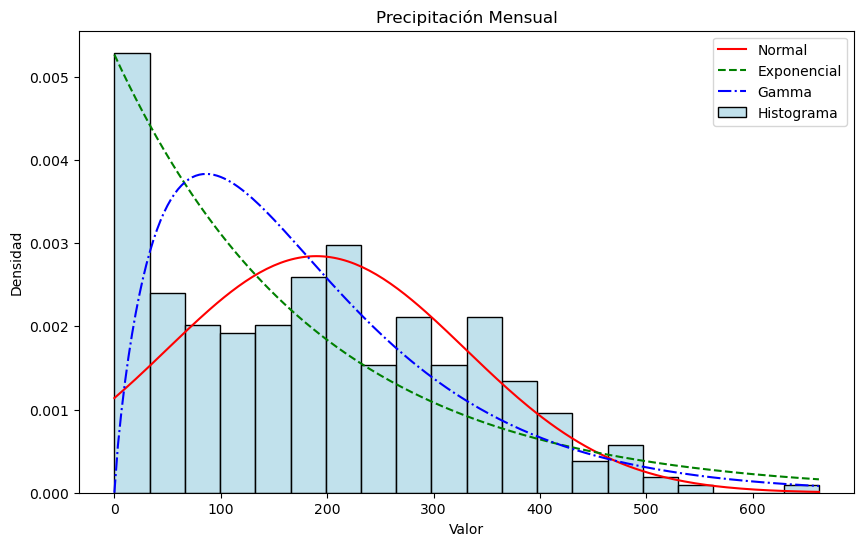

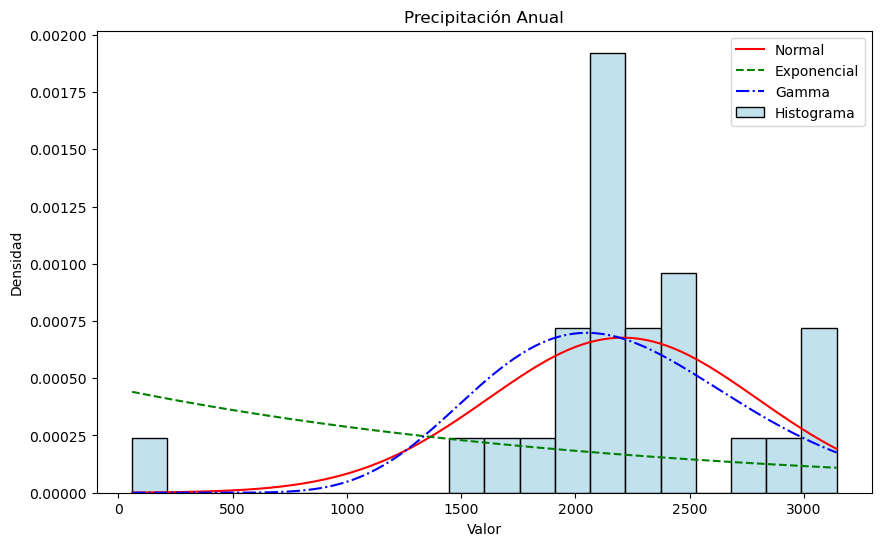

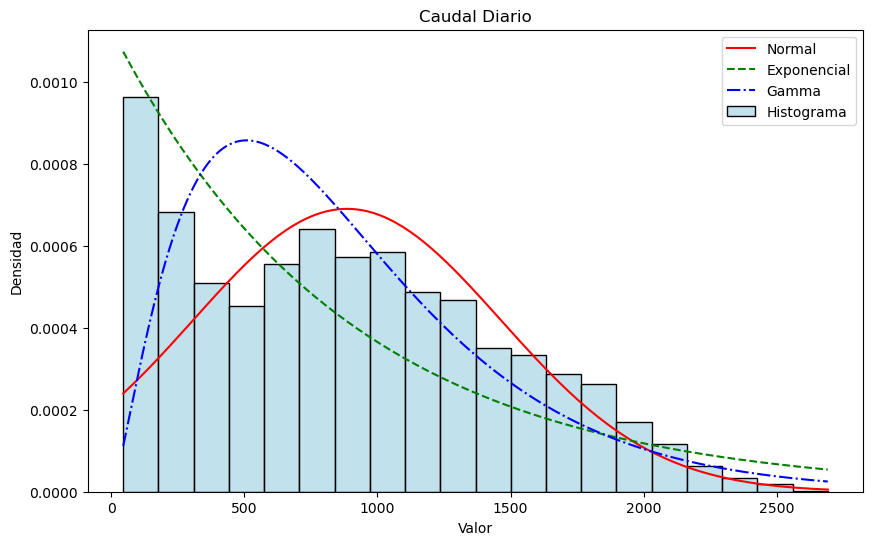

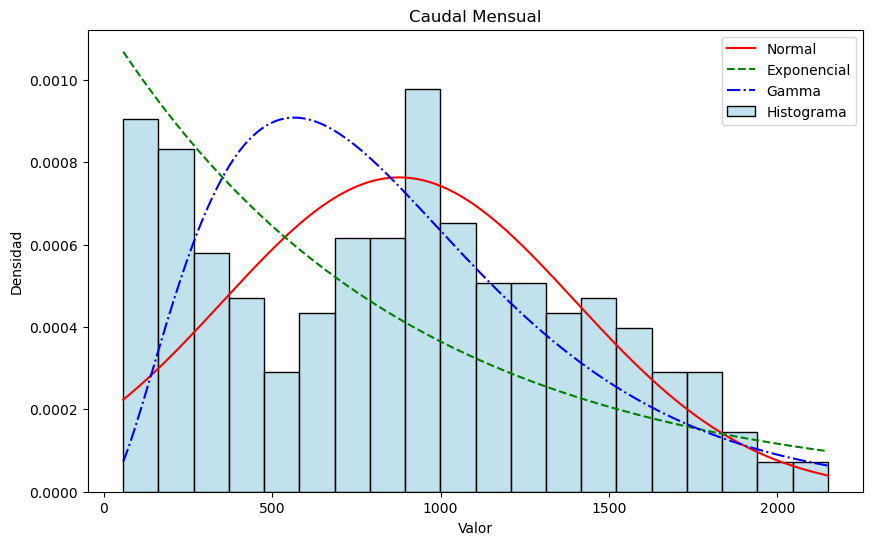

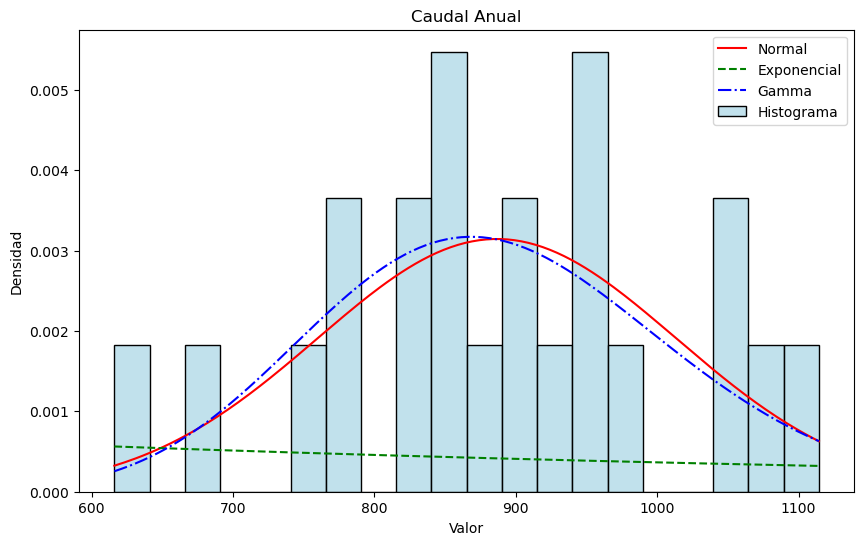

In [26]:
# ---- Precipitación ----
prec_mensual = df_p.resample('ME', on='Fecha')['Valor'].sum()
prec_anual = df_p.resample('YE', on='Fecha')['Valor'].sum()

plot_hist_fdps_manual(prec_mensual, 'Precipitación Mensual')
plot_hist_fdps_manual(prec_anual, 'Precipitación Anual')

# ---- Caudal ----
caudal_diario = df_c.set_index('Fecha')['Valor']
caudal_mensual = df_c.resample('ME', on='Fecha')['Valor'].mean()
caudal_anual = df_c.resample('YE', on='Fecha')['Valor'].mean()

plot_hist_fdps_manual(caudal_diario, 'Caudal Diario')
plot_hist_fdps_manual(caudal_mensual, 'Caudal Mensual')
plot_hist_fdps_manual(caudal_anual, 'Caudal Anual')

In [27]:
# ---- Función para calcular densidades sin scipy ----
def compute_fdps(data):
    x = np.linspace(data.min(), data.max(), 200)

    # Normal
    mu = data.mean()
    sigma = data.std()
    normal_pdf = (1/(sigma * np.sqrt(2*np.pi))) * np.exp(-0.5*((x-mu)/sigma)**2)

    # Exponencial
    lam = 1 / data.mean()
    expon_pdf = lam * np.exp(-lam * x)

    # Gamma
    mean = data.mean()
    var = data.var()
    alpha = mean**2 / var
    beta = var / mean
    gamma_pdf = np.zeros_like(x)
    gamma_pdf[x>0] = (x[x>0]**(alpha-1) * np.exp(-x[x>0]/beta)) / (beta**alpha * math.gamma(alpha))

    return x, normal_pdf, expon_pdf, gamma_pdf

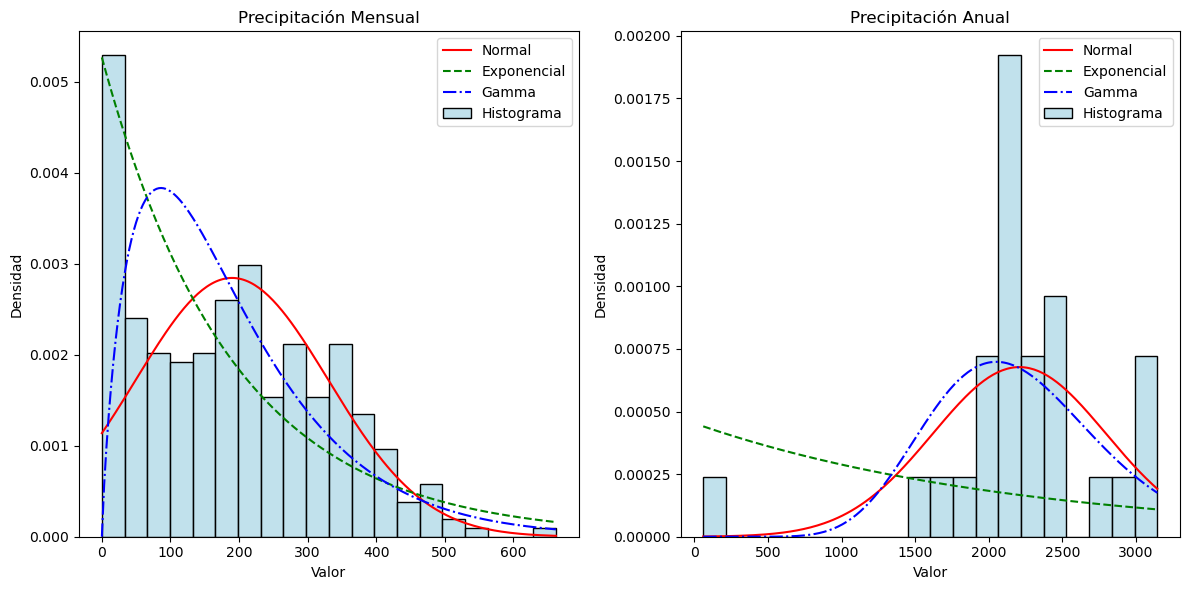

In [28]:
# ---- Precipitación ----
prec_mensual = df_p.resample('ME', on='Fecha')['Valor'].sum()
prec_anual = df_p.resample('YE', on='Fecha')['Valor'].sum()

prec_data = [prec_mensual, prec_anual]
prec_titles = ['Precipitación Mensual', 'Precipitación Anual']

plt.figure(figsize=(12,6))
for i, data in enumerate(prec_data):
    plt.subplot(1,2,i+1)
    sns.histplot(data, bins=20, stat='density', color='lightblue', label='Histograma')

    x, normal_pdf, expon_pdf, gamma_pdf = compute_fdps(data)
    plt.plot(x, normal_pdf, 'r-', label='Normal')
    plt.plot(x, expon_pdf, 'g--', label='Exponencial')
    plt.plot(x, gamma_pdf, 'b-.', label='Gamma')

    plt.title(prec_titles[i])
    plt.xlabel('Valor')
    plt.ylabel('Densidad')
    plt.legend()

plt.tight_layout()
plt.show()

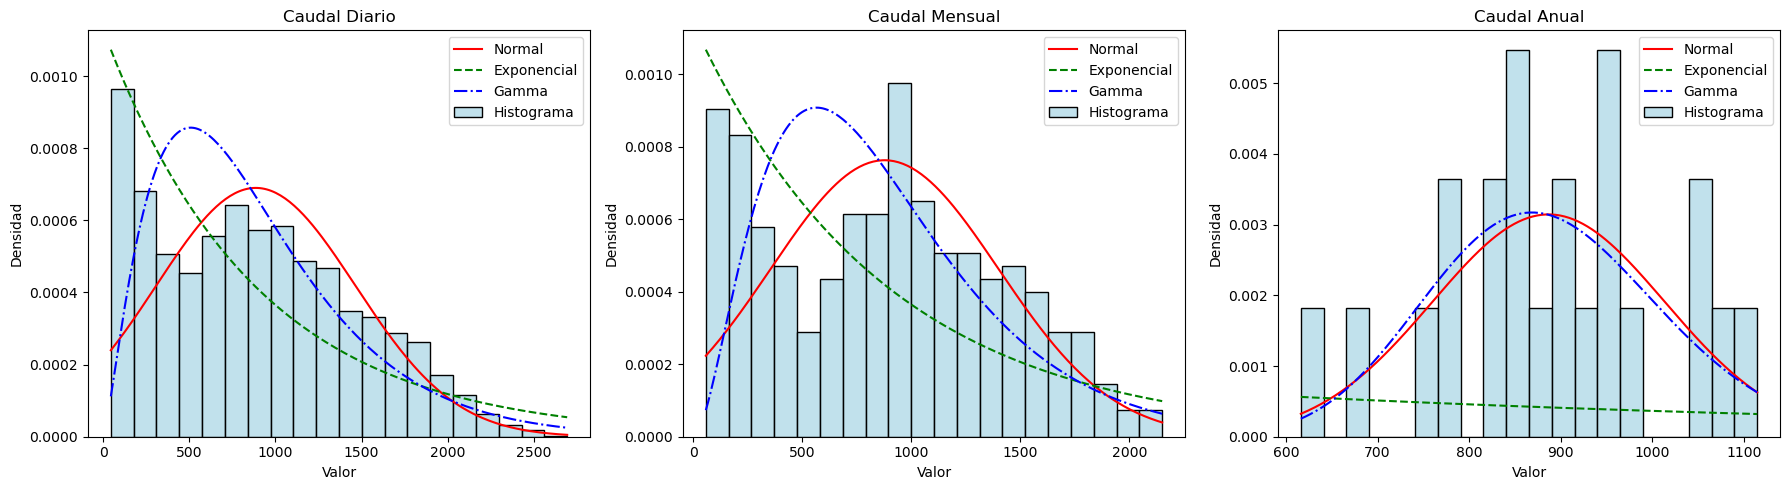

In [29]:
# ---- Caudal ----
caudal_diario = df_c.set_index('Fecha')['Valor']
caudal_mensual = df_c.resample('ME', on='Fecha')['Valor'].mean()
caudal_anual = df_c.resample('YE', on='Fecha')['Valor'].mean()

caudal_data = [caudal_diario, caudal_mensual, caudal_anual]
caudal_titles = ['Caudal Diario', 'Caudal Mensual', 'Caudal Anual']

plt.figure(figsize=(18,5))
for i, data in enumerate(caudal_data):
    plt.subplot(1,3,i+1)
    sns.histplot(data, bins=20, stat='density', color='lightblue', label='Histograma')

    x, normal_pdf, expon_pdf, gamma_pdf = compute_fdps(data)
    plt.plot(x, normal_pdf, 'r-', label='Normal')
    plt.plot(x, expon_pdf, 'g--', label='Exponencial')
    plt.plot(x, gamma_pdf, 'b-.', label='Gamma')

    plt.title(caudal_titles[i])
    plt.xlabel('Valor')
    plt.ylabel('Densidad')
    plt.legend()

plt.tight_layout()
plt.show()

En términos generales, la distribución de la precipitación a escala mensual presenta un sesgo positivo (hacia la derecha), lo cual es consistente con la naturaleza intermitente y altamente variable de esta variable. En este caso, la función de distribución de probabilidad (FDP) exponencial ofrece el mejor ajuste global, aunque no logra representar adecuadamente algunos intervalos, particularmente aquellos comprendidos entre 200 y 400 mm.

Por el contrario, a escala anual, los valores de precipitación tienden a concentrarse más hacia el centro de la distribución, mostrando un comportamiento más simétrico, con un ligero sesgo hacia valores altos. En este caso, la FDP exponencial presenta un ajuste deficiente, siendo más apropiadas distribuciones como la Gamma o incluso la Normal.

De manera similar a la precipitación, y como se evidenció en análisis previos, la distribución del caudal diario presenta un sesgo positivo, lo que permite que la FDP exponencial represente de forma aproximada su comportamiento. No obstante, para el caudal mensual, ninguna de las distribuciones evaluadas (exponencial, Normal o Gamma) logra capturar adecuadamente la forma de la distribución.

En particular, el caudal mensual presenta una estructura bimodal, evidenciada por la presencia de dos picos de densidad: uno cercano a la media y otro asociado a valores bajos. En este contexto, resulta más adecuado considerar el uso de una FDP bivariada o modelos mixtos que permitan representar esta dualidad en el comportamiento del caudal.

Finalmente, al analizar el caudal anual, se observa una mayor concentración de los valores alrededor del centro de la distribución. Sin embargo, la forma general sugiere un comportamiento cercano a una distribución uniforme con características bimodales, lo que indica la complejidad en la dinámica del caudal a escalas temporales agregadas.

# PUNTO 4

In [27]:
# ---- Función para estimar parámetros de Gumbel por MLE ----
def gumbel_mle_params(data):
    """
    Estimación aproximada de parámetros de Gumbel (mu, beta) por MLE
    """
    # Método de momentos aproximado: 
    # beta = std * sqrt(6)/pi, mu = mean - 0.5772*beta
    mean = data.mean()
    std = data.std()
    beta = std * np.sqrt(6)/np.pi
    mu = mean - 0.5772*beta
    return mu, beta

In [28]:
# ---- Función para graficar histograma y Gumbel ----
def plot_hist_gumbel(data, title):
    plt.figure(figsize=(8,5))
    sns.histplot(data, bins=15, stat='density', color='lightblue', label='Histograma')

    # Estimar parámetros Gumbel
    mu, beta = gumbel_mle_params(data)

    # Función de densidad de Gumbel
    x = np.linspace(data.min(), data.max(), 200)
    gumbel_pdf = (1/beta) * np.exp(-(x - mu)/beta) * np.exp(-np.exp(-(x - mu)/beta))
    plt.plot(x, gumbel_pdf, 'r-', label='Gumbel')

    plt.title(title)
    plt.xlabel('Valor')
    plt.ylabel('Densidad')
    plt.legend()
    plt.show()

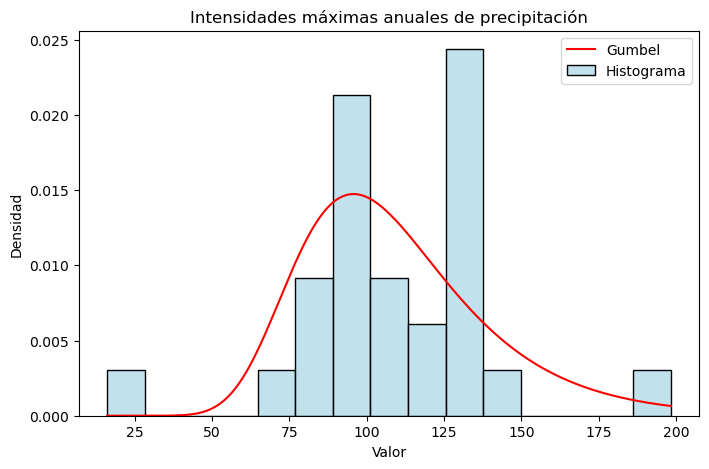

In [29]:
# ---- 1. Intensidades máximas anuales de precipitación ----
prec_max_anual = df_p.resample('YE', on='Fecha')['Valor'].max()
plot_hist_gumbel(prec_max_anual, 'Intensidades máximas anuales de precipitación')

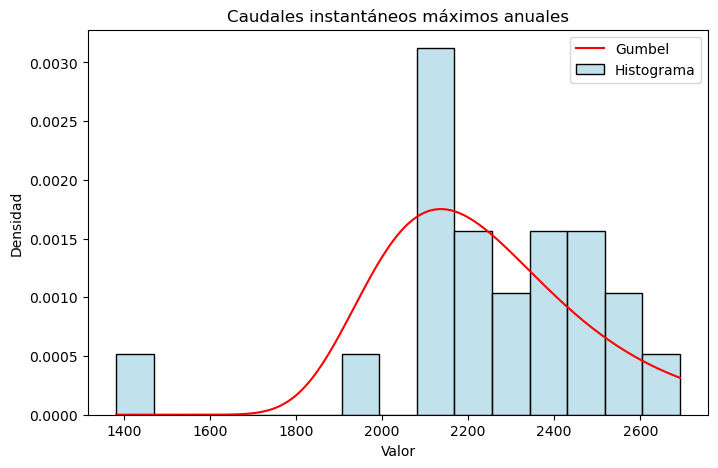

In [30]:
# ---- 2. Caudales instantáneos máximos anuales ----
# Asumimos que ya tienes la serie de máximos anuales en df_c['Valor']
caudal_max_instantaneo = df_c.resample('YE', on='Fecha')['Valor'].max()
plot_hist_gumbel(caudal_max_instantaneo, 'Caudales instantáneos máximos anuales')

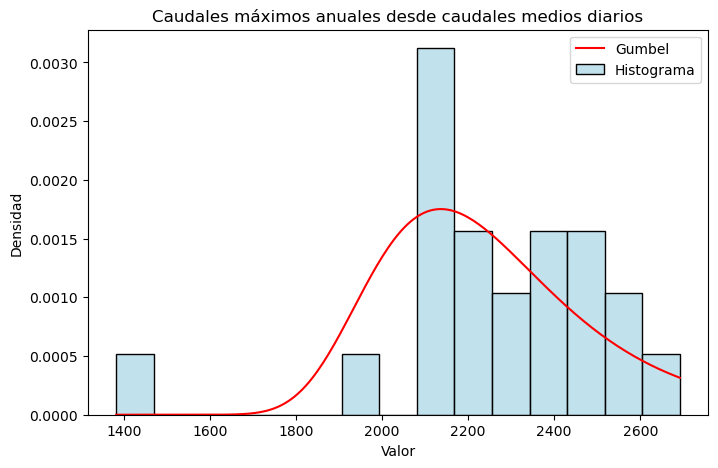

In [31]:
# ---- 3. Caudales máximos anuales desde caudales medios diarios ----
caudal_medio_diario = df_c.resample('D', on='Fecha')['Valor'].mean()
caudal_max_anual_desde_medio = caudal_medio_diario.resample('YE').max()
plot_hist_gumbel(caudal_max_anual_desde_medio, 'Caudales máximos anuales desde caudales medios diarios')

En este punto se analizan las intensidades máximas anuales de precipitación, los caudales máximos instantáneos anuales y los caudales máximos anuales obtenidos a partir de valores medios diarios.

Para cada caso, se realizó un ajuste utilizando la función de distribución de probabilidad (FDP) de Gumbel, obteniendo los siguientes resultados:

i) En el caso de las intensidades máximas anuales de precipitación, el ajuste resulta poco eficiente. Esto se debe a que los datos presentan un comportamiento bimodal, lo que dificulta que la distribución de Gumbel represente adecuadamente tanto la estructura general como los valores extremos.

ii) Para los caudales máximos instantáneos anuales, la distribución de Gumbel muestra un mejor desempeño. En particular, logra representar de manera adecuada los valores extremos, especialmente aquellos superiores a 2.100 m³/s, lo que indica su utilidad en el análisis de eventos hidrológicos extremos.

iii) En el caso de los caudales máximos anuales derivados de valores medios diarios, se observa un comportamiento similar al de los caudales instantáneos. La FDP de Gumbel captura razonablemente bien los valores extremos, aunque pueden persistir algunas limitaciones asociadas a la agregación temporal de los datos.

En conjunto, estos resultados evidencian que, si bien la distribución de Gumbel es ampliamente utilizada para el análisis de extremos, su desempeño puede verse limitado en variables que presentan estructuras multimodales o alta variabilidad interna.

# PUNTO 5

### CONVERT TO NETCDF

In [32]:
header = {}
with open("mdt_srtm.txt") as f:
    for _ in range(6):
        key, value = f.readline().split()
        header[key.lower()] = float(value) if "." in value else int(value)

In [33]:
ncols = header["ncols"]
nrows = header["nrows"]
cellsize = header["cellsize"]
nodata = header["nodata_value"]

In [34]:
import rioxarray

da = rioxarray.open_rasterio(
    "mdt_srtm.txt",
    chunks={"x": 2048, "y": 2048}
).squeeze()

da = da.astype("float32")

In [35]:
res_x, res_y = da.rio.resolution()
pixel_area = abs(res_x * res_y)  # m²

In [36]:
da

<xarray.DataArray (y: 62017, x: 45816)> Size: 11GB
dask.array<astype, shape=(62017, 45816), dtype=float32, chunksize=(2048, 2048), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 496kB 1.881e+06 1.881e+06 ... 2.078e+04 2.075e+04
  * x            (x) float64 367kB 4.446e+05 4.446e+05 ... 1.819e+06 1.819e+06
    band         int64 8B 1
    spatial_ref  int64 8B 0
Attributes:
    _FillValue:    -9999
    scale_factor:  1.0
    add_offset:    0.0

In [37]:
res_x = float(abs(da.x[1] - da.x[0]))
res_y = float(abs(da.y[1] - da.y[0]))

pixel_area = res_x * res_y   # m²

pixel_area_km2 = pixel_area / 1e6

In [38]:
import dask.array as dsa

In [39]:
elev = da.where(da != -9999)
bins = np.arange(0, 6000, 100)
counts, edges = dsa.histogram(elev.data, bins=bins)

In [40]:
counts = counts.compute()

In [41]:
area_km2 = counts * pixel_area_km2
centros = (edges[:-1] + edges[1:]) / 2

In [42]:
area_km2.sum()

np.float64(2556703.8134999997)

In [43]:
area_alta = (
    (da.data >= 2800)
    .sum(dtype="int64")
    .compute()
) * pixel_area_km2

print("Área alta montaña (km²):", float(area_alta))

Área alta montaña (km²): 43544.0628


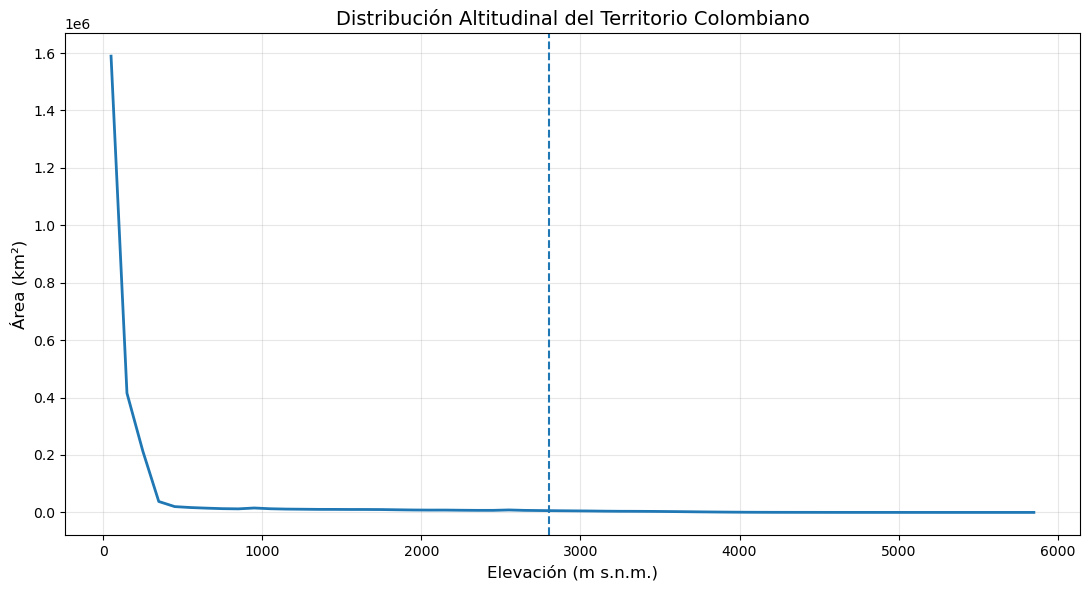

In [44]:
plt.figure(figsize=(11,6))

plt.plot(centros, area_km2, linewidth=2)

# Línea umbral alta montaña
plt.axvline(x=2800, linestyle="--")

plt.xlabel("Elevación (m s.n.m.)", fontsize=12)
plt.ylabel("Área (km²)", fontsize=12)
plt.title("Distribución Altitudinal del Territorio Colombiano", fontsize=14)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Al margen del error asociado al procesamiento del modelo digital de elevación (DEM), que sobreestima el área en aproximadamente un millón de km² respecto al valor real, es posible identificar patrones espaciales relevantes en la distribución altitudinal del territorio colombiano.

Se observa que entre 0 y aproximadamente 500 msnm se concentra la mayor parte del territorio nacional. Desde una perspectiva geográfica, este rango altitudinal corresponde principalmente a las regiones de la Orinoquía, la Amazonía, así como a las planicies costeras del Caribe y del Pacífico.

Por otro lado, la línea roja punteada indica el umbral de los 2.800 msnm, comúnmente asociado a zonas de alta montaña. Por encima de esta cota, el área acumulada es considerablemente reducida, lo que refleja que los ecosistemas altoandinos, en particular los páramos, representan una fracción muy pequeña del territorio nacional.

No obstante, a pesar de su limitada extensión, estas zonas de alta montaña tienen una importancia hidrológica fundamental, ya que funcionan como áreas clave de regulación y recarga hídrica.

In [45]:
da = da.chunk({"y": 2048, "x": 2048})

da.to_netcdf(
    "mdt_srtm_colombia.nc",
    engine="netcdf4"
)